In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
import os
path = "/content/drive/MyDrive/ML Projects/CIFAR10/cifar-10-python.tar.gz"
print(os.path.exists(path))

True


In [97]:
!cp "/content/drive/MyDrive/ML Projects/CIFAR10/cifar-10-python.tar.gz" "/content/"

In [98]:
import os

print(os.path.getsize("/content/cifar-10-python.tar.gz") / (1024**2), "MB")

162.59963130950928 MB


In [99]:
!tar -xzf "/content/cifar-10-python.tar.gz" -C "/content/"

In [100]:
import os

print(os.path.exists("/content/cifar-10-batches-py"))

True


In [101]:
import pickle
import numpy as np

data_path = "/content/cifar-10-batches-py"

def load_batch(file):
    with open(file, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    return batch[b"data"], batch[b"labels"]

In [102]:
X_batch, y_batch = load_batch(
    f"{data_path}/data_batch_1"
)

print(X_batch.shape)
print(len(y_batch))

(10000, 3072)
10000


In [103]:
len(X_batch[0])

3072

In [104]:
image = X_batch[0].reshape(3,32,32)
print("Before Transpose : ", image.shape)

Before Transpose :  (3, 32, 32)


In [105]:
image_rgb = image.transpose(1, 2, 0)
print("After Transpose : ", image_rgb.shape)

After Transpose :  (32, 32, 3)


In [106]:
X_train_list = []
y_train_list = []

for i in range(1, 6):
    X, y = load_batch(f"{data_path}/data_batch_{i}")
    X_train_list.append(X)
    y_train_list.extend(y)

X_train = np.concatenate(X_train_list)
y_train = np.array(y_train_list)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (50000, 3072)
y_train: (50000,)


In [107]:
X_test, y_test = load_batch(
    f"{data_path}/test_batch"
)

print("X_test:", X_test.shape)
print("y_test:", np.array(y_test).shape)

X_test: (10000, 3072)
y_test: (10000,)


In [108]:
print(y_train[:10])
print(y_test[:10])

[6 9 9 4 1 1 2 7 8 3]
[3, 8, 8, 0, 6, 6, 1, 6, 3, 1]


In [109]:
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (50000, 32, 32, 3)
X_test: (10000, 32, 32, 3)


In [110]:
print(X_train.dtype)
print(X_train.min())
print(X_train.max())

uint8
0
255


In [111]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

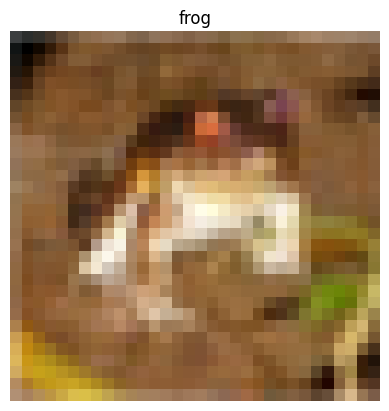

In [112]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0])
plt.title(class_names[y_train[0]])
plt.axis("off")
plt.show()

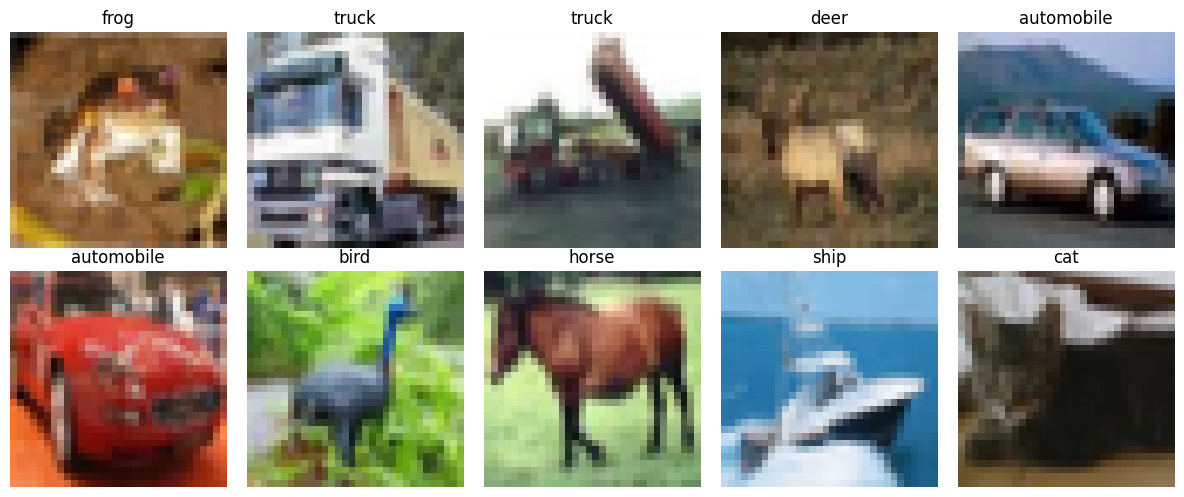

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [114]:
print("Min Pixel Value ", X_train.min())
print("Max Pixel Value ", X_train.max())
print("Data Type", X_train.dtype)

Min Pixel Value  0
Max Pixel Value  255
Data Type uint8


In [115]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

print("Min Pixel Value ", X_train.min())
print("Max Pixel Value ", X_train.max())

Min Pixel Value  0.0
Max Pixel Value  255.0


In [116]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min Pixel Value ", X_train.min())
print("Max Pixel Value ", X_train.max())

Min Pixel Value  0.0
Max Pixel Value  1.0


In [117]:
import tensorflow as tf
random_flip = tf.keras.layers.RandomFlip(mode = "horizontal")

In [118]:
image = X_train[0]

flipped_image = random_flip(
    tf.expand_dims(image,axis=0),
    training = True
)
print(flipped_image.shape)

(1, 32, 32, 3)


In [119]:
flipped_image = tf.image.flip_left_right(image)

print(tf.reduce_max(tf.abs(image - flipped_image)))

tf.Tensor(0.7529412, shape=(), dtype=float32)


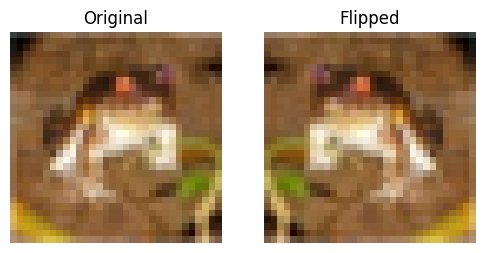

In [120]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flipped_image)
plt.title("Flipped")
plt.axis("off")

plt.show()

In [121]:
random_translate = tf.keras.layers.RandomTranslation(
    height_factor=0.1,
    width_factor=0.1
)

In [122]:
translated_image = random_translate(
    tf.expand_dims(image, axis=0),
    training=True
)

print(translated_image.shape)

(1, 32, 32, 3)


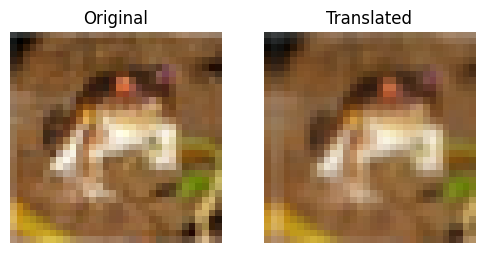

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(translated_image[0])
plt.title("Translated")
plt.axis("off")

plt.show()

In [124]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (45000, 32, 32, 3)
y_train: (45000,)
X_val: (5000, 32, 32, 3)
y_val: (5000,)


In [125]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomTranslation(
    height_factor=0.1,
    width_factor=0.1
),
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(units=128,
        activation="relu"
    ),

    tf.keras.layers.Dense(units=10,
        activation="softmax"
    )
])


In [126]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_3            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [128]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 119ms/step - accuracy: 0.4249 - loss: 1.5888 - val_accuracy: 0.5478 - val_loss: 1.2825
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 120ms/step - accuracy: 0.5491 - loss: 1.2695 - val_accuracy: 0.6012 - val_loss: 1.1310
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.5944 - loss: 1.1519 - val_accuracy: 0.6332 - val_loss: 1.0426
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 115ms/step - accuracy: 0.6189 - loss: 1.0782 - val_accuracy: 0.6524 - val_loss: 0.9850
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 111ms/step - accuracy: 0.6394 - loss: 1.0290 - val_accuracy: 0.6730 - val_loss: 0.9364
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 117ms/step - accuracy: 0.6502 - loss: 0.9898 - val_accuracy: 0.6932 - val_loss: 0.8837
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6643 - loss: 0.9536 - val_accuracy: 0.6860 - val_loss: 0.9134
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.6751 - loss: 

In [129]:
y_test = np.array(y_test)

In [130]:
print(type(X_test))
print(X_test.shape)
print(X_test.dtype)

<class 'numpy.ndarray'>
(10000, 32, 32, 3)
float32


In [131]:
print(type(y_test))
print(y_test.shape)
print(y_test.dtype)

<class 'numpy.ndarray'>
(10000,)
int64


In [132]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7081 - loss: 0.8460


In [133]:
model.save(
    "/content/drive/MyDrive/ML Projects/CIFAR10/baseline_cnn.keras"
)

In [134]:
import pickle

with open(
    "/content/drive/MyDrive/ML Projects/CIFAR10/baseline_history.pkl",
    "wb"
) as f:
    pickle.dump(history.history, f)

In [135]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

In [136]:
print(base_model.summary())

Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [137]:
base_model.trainable = False

In [138]:
print("Trainable", base_model.trainable)
print("Trainable Parameters : ", len(base_model.trainable_weights) )

Trainable False
Trainable Parameters :  0


In [139]:
model_tl = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Resizing(96,96),

    tf.keras.layers.Rescaling(
        scale=2.0,
        offset=-1.0
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(10, activation="softmax")
])

In [140]:
model_tl.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [141]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [142]:
history_tl = model_tl.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 341s 477ms/step - accuracy: 0.8095 - loss: 0.5559 - val_accuracy: 0.8580 - val_loss: 0.4161
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 386s 483ms/step - accuracy: 0.8638 - loss: 0.3949 - val_accuracy: 0.8602 - val_loss: 0.4083
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 340s 484ms/step - accuracy: 0.8743 - loss: 0.3596 - val_accuracy: 0.8602 - val_loss: 0.3939
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 384s 486ms/step - accuracy: 0.8825 - loss: 0.3366 - val_accuracy: 0.8650 - val_loss: 0.3910
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 341s 484ms/step - accuracy: 0.8895 - loss: 0.3223 - val_accuracy: 0.8678 - val_loss: 0.3851


In [143]:
import numpy as np

# Ensure y_test is a numpy array
y_test_arr = np.array(y_test)

test_loss_tl, test_acc_tl = model_tl.evaluate(
    X_test,
    y_test_arr,
    batch_size=64
)

print("Test accuracy:", test_acc_tl)

157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 433ms/step - accuracy: 0.8591 - loss: 0.4139
Test accuracy: 0.8590999841690063


In [144]:
model_tl.save(
    "/content/drive/MyDrive/ML Projects/CIFAR10/mobilenetv2_feature_extraction.keras"
)

In [145]:
import pickle

with open(
    "/content/drive/MyDrive/ML Projects/CIFAR10/mobilenetv2_feature_history.pkl",
    "wb"
) as f:
    pickle.dump(history_tl.history, f)

In [146]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

In [147]:
trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("Trainable backbone layers:", len(trainable_layers))
print(trainable_layers)

Trainable backbone layers: 19
['block_14_expand', 'block_14_expand_relu', 'block_14_depthwise', 'block_14_depthwise_relu', 'block_14_project', 'block_14_add', 'block_15_expand', 'block_15_expand_relu', 'block_15_depthwise', 'block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_relu', 'block_16_project', 'Conv_1', 'out_relu']


In [148]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [149]:
history_ft = model_tl.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 475s 666ms/step - accuracy: 0.9046 - loss: 0.2750 - val_accuracy: 0.8794 - val_loss: 0.3617
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 505s 670ms/step - accuracy: 0.9261 - loss: 0.2187 - val_accuracy: 0.8838 - val_loss: 0.3455
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 470s 667ms/step - accuracy: 0.9424 - loss: 0.1765 - val_accuracy: 0.8868 - val_loss: 0.3448
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 474s 674ms/step - accuracy: 0.9544 - loss: 0.1444 - val_accuracy: 0.8924 - val_loss: 0.3360
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 474s 673ms/step - accuracy: 0.9661 - loss: 0.1162 - val_accuracy: 0.8920 - val_loss: 0.3332


In [150]:
test_loss_ft, test_acc_ft = model_tl.evaluate(
    X_test,
    y_test_arr,
    batch_size=64
)

print("Fine-tuned test accuracy:", test_acc_ft)

157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 410ms/step - accuracy: 0.8851 - loss: 0.3619
Fine-tuned test accuracy: 0.8851000070571899


In [151]:
model_tl.save(
    "/content/drive/MyDrive/ML Projects/CIFAR10/mobilenetv2_finetuned.keras"
)

In [152]:
import pickle

with open(
    "/content/drive/MyDrive/ML Projects/CIFAR10/finetune_history.pkl",
    "wb"
) as f:
    pickle.dump(history_ft.history, f)

In [153]:
y_prob = model_tl.predict(
    X_test,
    batch_size=64
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 427ms/step


In [154]:
y_pred = np.argmax(y_prob, axis = 1)

In [155]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_arr, y_pred)

print(cm)

[[898   5  15   4  12   0   2   1  48  15]
 [  4 946   0   1   0   1   5   0   7  36]
 [ 19   1 846  39  43  12  29   9   2   0]
 [  7   2  19 821  33  69  26   8   9   6]
 [  6   2  28  30 883  15  17  18   1   0]
 [  3   1   9 137  19 790  12  25   4   0]
 [  4   0  13  39  15  12 913   2   2   0]
 [  9   1   8  24  41  23   5 879   4   6]
 [ 36   8   3   3   0   0   1   0 940   9]
 [ 13  32   1   3   1   1   2   1  11 935]]


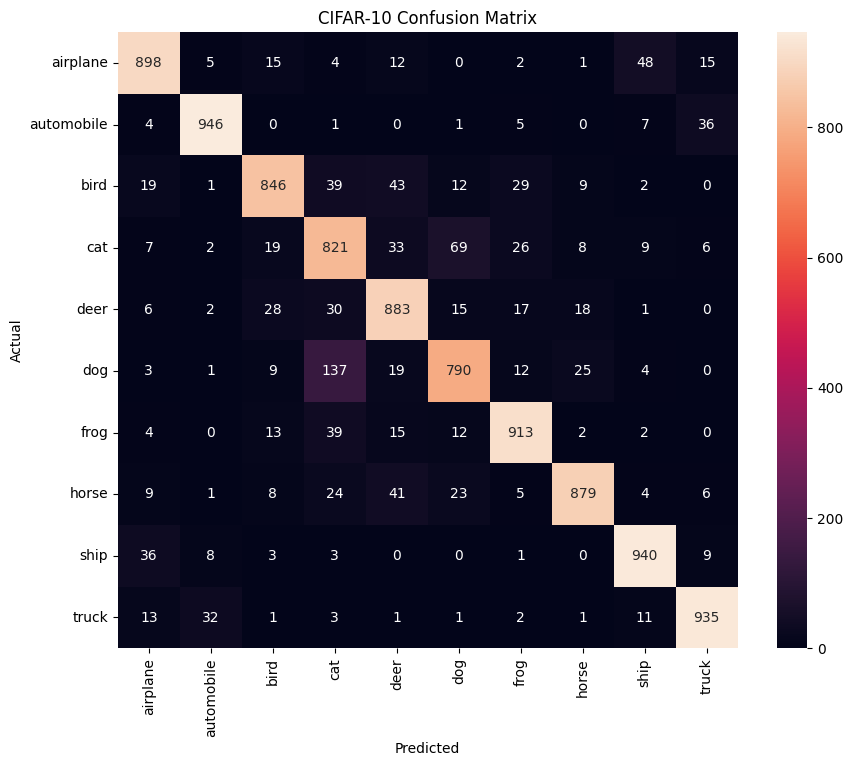

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

In [157]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_arr,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.90      0.90      0.90      1000
  automobile       0.95      0.95      0.95      1000
        bird       0.90      0.85      0.87      1000
         cat       0.75      0.82      0.78      1000
        deer       0.84      0.88      0.86      1000
         dog       0.86      0.79      0.82      1000
        frog       0.90      0.91      0.91      1000
       horse       0.93      0.88      0.90      1000
        ship       0.91      0.94      0.93      1000
       truck       0.93      0.94      0.93      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [158]:
misclassified_indices = np.where(y_test_arr != y_pred)[0]

print("Misclassified Count:", len(misclassified_indices))

Misclassified Count: 1149


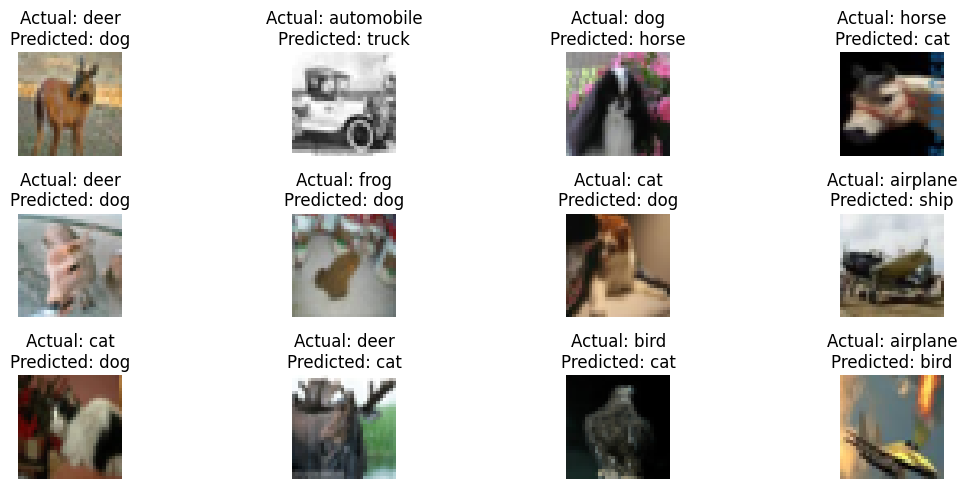

In [159]:
plt.figure(figsize=(12, 5))

for i, idx in enumerate(misclassified_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])
    plt.title(
        f"Actual: {class_names[y_test_arr[idx]]}\n"
        f"Predicted: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [160]:
dog_as_catt = np.where(
    (y_test_arr == 5) & (y_pred == 3)
)[0]
print("Dog as Cat Count:", len(dog_as_catt))

Dog as Cat Count: 137


In [161]:
dog_as_cat = np.where(
    (y_test_arr == class_names.index("dog")) &
     (y_pred == class_names.index("cat"))
)[0]

print("Dog as Cat Count:", len(dog_as_cat))

Dog as Cat Count: 137


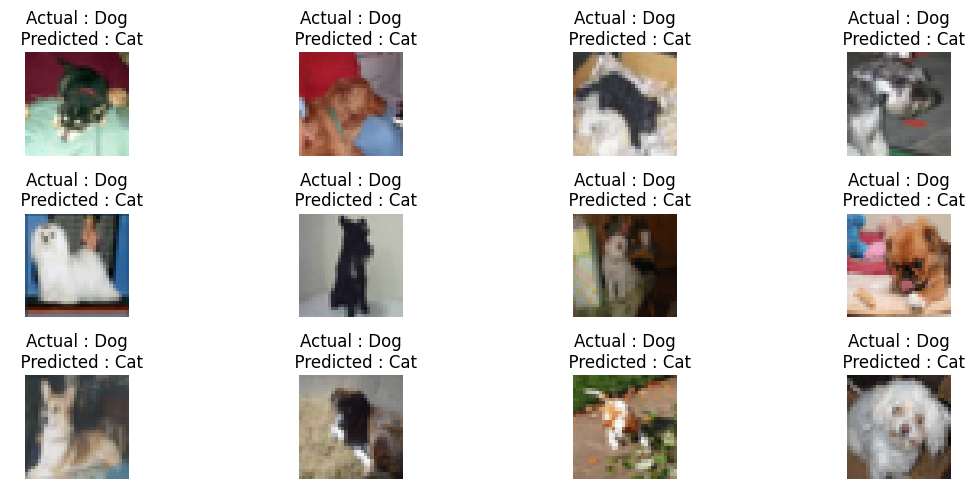

In [162]:
plt.figure(figsize = (12, 5))

for i , idx in enumerate(dog_as_cat[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])
    plt.title(
        "Actual : Dog\n  Predicted : Cat" )
    plt.axis("off")
plt.tight_layout()
plt.show()

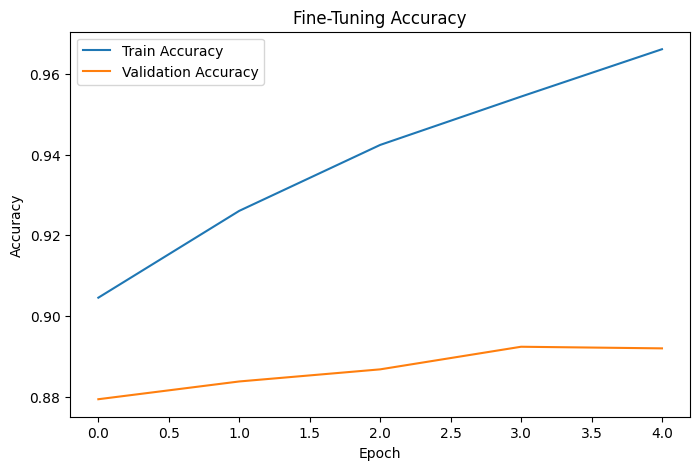

In [163]:
plt.figure(figsize=(8, 5))

plt.plot(history_ft.history["accuracy"], label="Train Accuracy")
plt.plot(history_ft.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.legend()
plt.show()

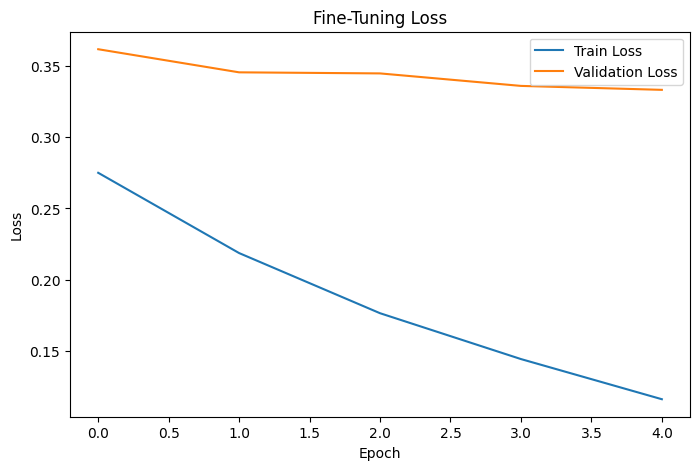

In [164]:
plt.figure(figsize=(8, 5))

plt.plot(history_ft.history["loss"], label="Train Loss")
plt.plot(history_ft.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss")
plt.legend()
plt.show()

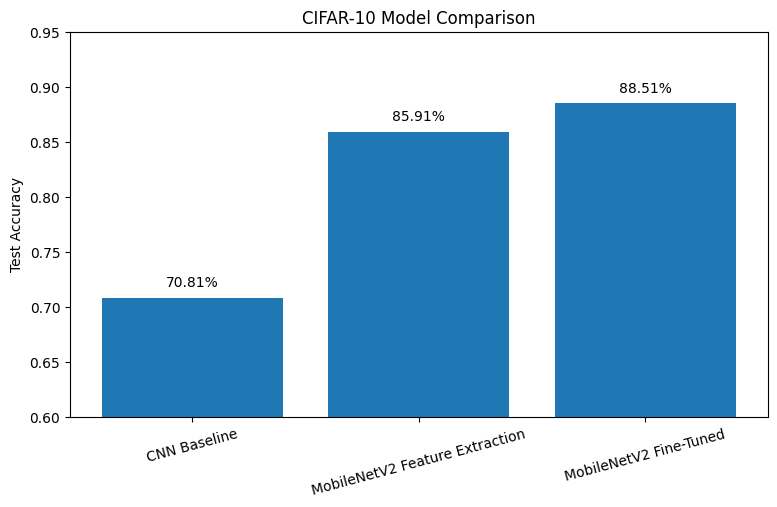

In [169]:
models = [
    "CNN Baseline",
    "MobileNetV2 Feature Extraction",
    "MobileNetV2 Fine-Tuned"
]

accuracies = [
    0.7081,
    0.8591,
    0.8851
]

plt.figure(figsize=(9, 5))

plt.bar(models, accuracies)

plt.ylabel("Test Accuracy")
plt.title("CIFAR-10 Model Comparison")
plt.ylim(0.6, 0.95)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc*100:.2f}%", ha="center")

plt.xticks(rotation=15)
plt.show()

In [170]:
import json

results = {
    "baseline_cnn_test_accuracy": 0.7081,
    "mobilenetv2_feature_extraction_test_accuracy": 0.8591,
    "mobilenetv2_finetuned_test_accuracy": 0.8851
}

with open(
    "/content/drive/MyDrive/ML Projects/CIFAR10/results.json",
    "w"
) as f:
    json.dump(results, f, indent=4)

In [171]:
import os

project_path = "/content/drive/MyDrive/ML Projects/CIFAR10"

for root, dirs, files in os.walk(project_path):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/ML Projects/CIFAR10/cifar-10-python.tar.gz
/content/drive/MyDrive/ML Projects/CIFAR10/baseline_cnn.keras
/content/drive/MyDrive/ML Projects/CIFAR10/baseline_history.pkl
/content/drive/MyDrive/ML Projects/CIFAR10/CIFAR_Transfer_Learning.ipynb
/content/drive/MyDrive/ML Projects/CIFAR10/mobilenetv2_feature_extraction.keras
/content/drive/MyDrive/ML Projects/CIFAR10/mobilenetv2_feature_history.pkl
/content/drive/MyDrive/ML Projects/CIFAR10/mobilenetv2_finetuned.keras
/content/drive/MyDrive/ML Projects/CIFAR10/finetune_history.pkl
/content/drive/MyDrive/ML Projects/CIFAR10/results.json
